In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything works!")

Everything works!


In [54]:
# Data Loading 

df = pd.read_csv("../data/customer_churn.csv")

# Data Exploration

df.head()

# Will display a table with the clients data, including whether they have churned or not.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

# Will display the number of rows and columns in the dataset. In this case, there are 7043 rows and 21 columns.

(7043, 21)

In [55]:
df.info()

# Will display information about the dataset, including the data types of each column and the number of non-null values.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# Data Analysis

df["Churn"].value_counts(normalize=True) * 100 

# Will display the percentage of clients who have churned and those who have not. In this case, 26.54% of clients have churned, while 73.46% have not.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

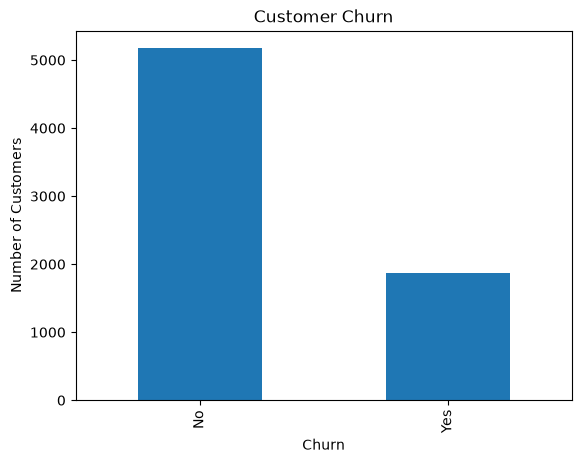

In [ ]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# Will display a bar chart showing the number of customers who have churned and those who have not. The x-axis will show "Churn" and the y-axis will show the number of customers.

In [ ]:
df.groupby("Churn")["tenure"].mean()

# Will display the average tenure of customers who have churned and those who have not. In this case, customers who have churned have an average tenure of 16.36 months, while those who have not churned have an average tenure of 37.35 months.
# This suggests that customers who have been with the company for a shorter period of time are more likely to churn.

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

# Will display the average monthly charges of customers who have churned and those who have not. In this case, customers who have churned have an average monthly charge of $70.35, while those who have not churned have an average monthly charge of $61.27.
# This suggests that customers who are paying higher monthly charges are more likely to churn.

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})
df["Churn"].head()

# Will convert the "Churn" column from categorical values ("Yes" and "No") to numerical values (1 and 0). This is often done to prepare the data for machine learning models, which typically require numerical input. After this code is executed, the "Churn" column will contain 1 for customers who have churned and 0 for those who have not.
# The `head()` function will display the first few rows of the "Churn" column after the mapping has been applied.


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [ ]:
df_ml = df.drop("customerID", axis=1)

df_ml.head()

# Will display the first few rows of the dataset after dropping the "customerID" column, which is not needed for machine learning models. The "customerID" column is typically a unique identifier for each customer and does not provide any predictive value for churn analysis.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
# Data Preparation

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df_ml = df.drop("customerID", axis=1)
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Will display the first few rows of the dataset after converting categorical variables into dummy/indicator variables. The `drop_first=True` parameter is used to avoid multicollinearity by dropping the first category of each categorical variable. This prepares the data for machine learning models that require numerical input. 
# Will show the first few rows of the dataset after this transformation, allowing the user to see how the categorical variables have been encoded into numerical format.

In [41]:
df_ml.shape

# Will display the number of rows and columns in the transformed dataset. The number of rows should remain the same, while the number of columns may increase due to the creation of dummy variables for categorical features.



(7043, 31)

In [42]:
# This will separate the features (X) from the target variable (y). The features will include all columns except for "Churn", while the target variable will be the "Churn" column itself.

X = df_ml.drop("Churn", axis=1)

y = df_ml["Churn"]

print(X.shape)
print(y.shape)

#The feature set should have the same number of rows as the original dataset, while the target variable should have one column representing whether each customer has churned or not.


(7043, 30)
(7043,)


In [ ]:
#Model Training

# This will split the dataset into training and testing sets. The training set will contain 80% of the data, while the testing set will contain 20%. The `random_state` parameter is set to 42 to ensure that the split is reproducible.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [44]:
# This will display the number of rows and columns in the training and testing sets. The training set should contain 80% of the original dataset, while the testing set should contain 20%. The number of columns should remain the same in both sets.
# This is the first machine learning model that will be used to predict customer churn and it is a logistic regression model. 
# Logistic regression is a statistical model that is used to predict the probability of a binary outcome, such as whether a customer will churn or not. It is a commonly used model for classification problems and is often used in churn analysis.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [58]:
#Model Evaluation

# This will display the first 10 predictions made by the model on the testing set. The predictions will be either 0 (indicating that the customer is predicted not to churn) or 1 (indicating that the customer is predicted to churn). 
# This allows the user to see how the model is performing on individual samples from the testing set.

y_pred = model.predict(X_test)

y_pred[:10]
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82


In [57]:

# This will display the precision, recall, f1-score, and support for each class (0 and 1) in the testing set. Precision is the number of true positive predictions divided by the total number of positive predictions, recall is the number of true positive predictions divided by the total number of actual positives, f1-score is the harmonic mean of precision and recall, and support is the number of actual occurrences of each class in the testing set. This report provides a more detailed evaluation of the model's performance beyond just accuracy.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

